<a href="https://colab.research.google.com/github/camille2019/Women-Capital-Trial-Analysis/blob/main/bootstrap_without_concat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bootstrap Word and N-gram Metrics

This notebook bootstraps corpus features (words and optional n-grams) and reports:
- Relative frequency statistics
- TF-IDF statistics
- Confidence intervals from bootstrap replicates

In [6]:
from __future__ import annotations

import csv
import math
import random
import re
import statistics
from collections import Counter
from pathlib import Path
from typing import Iterable
import numpy as np

In [2]:

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:


TOKEN_RE = re.compile(r"[A-Za-z0-9']+")

def collect_files(inputs: Iterable[Path], recursive: bool) -> list[Path]:
    files: list[Path] = []
    for item in inputs:
        if item.is_file():
            files.append(item)
        elif item.is_dir():
            if recursive:
                files.extend(p for p in item.rglob('*') if p.is_file())
            else:
                files.extend(p for p in item.iterdir() if p.is_file())
    return sorted(set(files))

def tokenize(text: str, lowercase: bool, min_len: int) -> list[str]:
    tokens = TOKEN_RE.findall(text)
    if lowercase:
        tokens = [t.lower() for t in tokens]
    return [t for t in tokens if len(t) >= min_len]

def read_documents(paths: list[Path], lowercase: bool, min_len: int) -> list[list[str]]:
    docs: list[list[str]] = []
    for path in paths:
        text = path.read_text(encoding='utf-8', errors='ignore')
        toks = tokenize(text, lowercase=lowercase, min_len=min_len)
        if toks:
            docs.append(toks)
    return docs

def normalize_feature(raw: str, lowercase: bool, min_len: int) -> str | None:
    parts = tokenize(raw, lowercase=lowercase, min_len=min_len)
    if not parts:
        return None
    if len(parts) == 1:
        return parts[0]
    return '_'.join(parts)

def load_selected_features(select_items: list[str], lowercase: bool, min_len: int) -> set[str] | None:
    if not select_items:
        return None
    out: set[str] = set()
    for item in select_items:
        for part in item.split(','):
            feature = normalize_feature(part.strip(), lowercase=lowercase, min_len=min_len)
            if feature:
                out.add(feature)
    return out

def make_doc_features(docs: list[list[str]], ngrams: list[int], selected: set[str] | None) -> tuple[list[Counter[str]], set[str]]:
    ngram_set = sorted({n for n in ngrams if n >= 2})
    out_docs: list[Counter[str]] = []
    vocab: set[str] = set()
    for toks in docs:
        counts: Counter[str] = Counter()
        for t in toks:
            if selected is None or t in selected:
                counts[t] += 1
        for n in ngram_set:
            if len(toks) < n:
                continue
            for i in range(len(toks) - n + 1):
                ng = '_'.join(toks[i:i+n])
                if selected is None or ng in selected:
                    counts[ng] += 1
        if counts:
            out_docs.append(counts)
            vocab.update(counts.keys())
    return out_docs, vocab

def quantile(sorted_values: list[float], q: float) -> float:
    if not sorted_values:
        return 0.0
    if q <= 0:
        return sorted_values[0]
    if q >= 1:
        return sorted_values[-1]
    pos = (len(sorted_values) - 1) * q
    lo = int(pos)
    hi = min(lo + 1, len(sorted_values) - 1)
    frac = pos - lo
    return sorted_values[lo] * (1 - frac) + sorted_values[hi] * frac

def bootstrap_feature_metrics(docs: list[Counter[str]], vocab: set[str], rounds: int, seed: int | None) -> tuple[dict[str, list[float]], dict[str, list[float]], int]:
    rng = random.Random(seed)
    per_feature_freq: dict[str, list[float]] = {f: [] for f in sorted(vocab)}
    per_feature_tfidf: dict[str, list[float]] = {f: [] for f in sorted(vocab)}
    total_tokens = sum(sum(d.values()) for d in docs)
    n_docs = len(docs)

    for _ in range(rounds):
        sample_docs = [rng.choice(docs) for _ in range(len(docs))]
        counts = Counter()
        doc_freq = Counter()
        sample_tokens = 0
        for d in sample_docs:
            counts.update(d)
            doc_freq.update(d.keys())
            sample_tokens += sum(d.values())

        if sample_tokens == 0:
            for f in per_feature_freq:
                per_feature_freq[f].append(0.0)
                per_feature_tfidf[f].append(0.0)
            continue

        for f in per_feature_freq:
            tf = counts[f] / sample_tokens
            idf = math.log((1 + n_docs) / (1 + doc_freq[f])) + 1
            per_feature_freq[f].append(tf)
            per_feature_tfidf[f].append(tf * idf)

    return per_feature_freq, per_feature_tfidf, total_tokens

def summarize_metric(per_feature: dict[str, list[float]], alpha: float) -> dict[str, tuple[float, float, float, float]]:
    low_q = alpha / 2
    high_q = 1 - (alpha / 2)
    out: dict[str, tuple[float, float, float, float]] = {}
    for feature, vals in per_feature.items():
        sorted_vals = sorted(vals)
        mean = statistics.fmean(vals) if vals else 0.0
        median = quantile(sorted_vals, 0.5)
        low = quantile(sorted_vals, low_q)
        high = quantile(sorted_vals, high_q)
        out[feature] = (mean, median, low, high)
    return out

def summarize(per_feature_freq: dict[str, list[float]], per_feature_tfidf: dict[str, list[float]], alpha: float) -> list[tuple[str, float, float, float, float, float, float, float, float]]:
    freq_stats = summarize_metric(per_feature_freq, alpha=alpha)
    tfidf_stats = summarize_metric(per_feature_tfidf, alpha=alpha)
    rows: list[tuple[str, float, float, float, float, float, float, float, float]] = []
    for feature in per_feature_freq:
        f_mean, f_median, f_low, f_high = freq_stats[feature]
        t_mean, t_median, t_low, t_high = tfidf_stats[feature]
        rows.append((feature, f_mean, f_median, f_low, f_high, t_mean, t_median, t_low, t_high))
    rows.sort(key=lambda x: x[1], reverse=True)
    return rows

def write_csv(rows: list[tuple[str, float, float, float, float, float, float, float, float]], out_path: Path | str | None, top_k: int | None) -> None:
    head = rows[:top_k] if top_k else rows
    fieldnames = [
        'feature',
        'mean_freq',
        'median_freq',
        'freq_ci_low',
        'freq_ci_high',
        'mean_tfidf',
        'median_tfidf',
        'tfidf_ci_low',
        'tfidf_ci_high',
    ]

    if out_path:
        out = Path(out_path).expanduser() if isinstance(out_path, str) else out_path
        with out.open('w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(fieldnames)
            writer.writerows(head)
    else:
        print(','.join(fieldnames))
        for row in head:
            print(','.join(str(x) for x in row))

In [4]:
#december updated keywords 12/18


#some keywords should be counted with whitespace/nonalphabeteical before and after

stems = {'flaunt', 'appeal', 'reveal', 'sex', 'teas', 'lur', 'ethnic', 'flirt', 'seduc','adulter' , 'promiscu', 'charm', 'glamour', 'slut', 'figure hug','tight fit' ,
          'nurtur', 'neglect',
         'irrational', 'hysteri', 'scheme', 'cry', 'manipulat',
         'infiltrat',
         'addict', 'drug'

         }

full_words = {'underwear', 'affair', 'sexy', 'attractive','ass', 'booty', 'oversexed', 'busty', 'bra', 'panty', 'lingerie', 'teddy', 'whore', 'bimbo', 'floozy','bitch', 'jezebel','mistress', 'breast', 'cleavage', 'skank','cougar', 'temptress', 'short skirt', 'low cut', 'boxers', 'womanizer',
              'child abuse', 'family oriented', 'caring', 'negligent','therapy', 'respect', 'foster', 'minor', 'parents', 'therapist','bad mom', 'bad mother', 'maternal', 'matriarch', 'bad dad', 'bad father','paternal', 'patriarch',

              'calculated', 'cold', 'inhuman', 'unnatural', 'unstable',  'fake', 'deranged','tears', 'unemotional', 'liar', 'malinger', 'uncontrollable', 'angry', 'insincere', 'not crying', 'unempathetic', 'no empathy', 'lie', 'lies',


'nurture', 'homemaker', 'virgin','pure', 'sacrificial','cold', 'uncaring', 'unfriendly', 'unemotional','abandonment', 'overbearing','selfish', 'unnatural', 'assertive','ugly', 'aggressive','confrontational', 'violent', 'unfeeling','family oriented', 'physically attractive','sexual appeal', 'child abuse','emotionally abusive',   'caring', 'friendly', 'emotional', 'sex appeal', 'maternal','feminine','wife', 'lady', 'woman','housewife'
           ,'alien', 'foreign', 'backward','home', 'citizenship', 'wetback','illegal', 'dirty','untrustworthy','exotic', 'diverse', 'different', 'ethnic','accent', 'english', 'custom', 'culture','steal',
              'cocaine', 'speed', 'marijuana', 'heroin', 'methamphetamine', 'brain', 'meth' ,'influence' ,'nanograms' ,'alcohol' ,'stimulant' ,'valium', 'crack' ,'crystal' ,'gram',  'crack house',

              }

#organized by theme and gendering
# 4 categories with gendered and neutral terms
hypersexualize_f = {'busty', 'bra', 'panty', 'lingerie', 'teddy','slut',  'whore', 'bimbo', 'floozy','bitch', 'jezebel',
'mistress', 'breast', 'cleavage', 'skank','cougar', 'temptress','short skirt', 'low cut','figure hug','tight fit' }
hypersexualize_m = {'boxers', 'womanizer'}
hypersexualize_n = {'flaunt', 'appeal', 'reveal', 'underwear', 'sex', 'teas',  'lur', 'entic', 'flirt', 'seduc', 'affair', 'adulter', 'promiscu', 'charm', 'sexy', 'glamour', 'attractive','ass', 'booty', 'oversexed' }
all_hypersexualize = hypersexualize_f | hypersexualize_m | hypersexualize_n

parenting_f={'bad mom', 'bad mother', 'maternal', 'matriarch'}
parenting_m ={ 'bad dad', 'bad father','paternal', 'patriarch'}
parenting_n ={ 'child abuse', 'family oriented', 'caring', 'negligent', 'nurtur', 'neglect', 'therapy', 'respect', 'foster', 'minor', 'parents', 'therapist'  }
parenting_all= parenting_f |parenting_m | parenting_n

pathologizing = {'calculated', 'cold', 'inhuman', 'unnatural', 'unstable',  'fake', 'deranged','tears', 'unemotional', 'liar', 'malinger', 'uncontrollable', 'angry', 'insincere', 'not crying', 'unempathetic', 'no empathy', 'lie', 'lies',
'irrational', 'hysteri', 'scheme', 'cry', 'manipulat'}

sexuality_f = {'bitch', 'dyke', 'butch','lesbian'}
sexuality_m = {'gay'}
sexuality_n = {'bisexual', 'queer'}
all_sexuality = sexuality_f | sexuality_m | sexuality_n

gender_f = {'maternal','feminine','wife', 'lady', 'woman','housewife', 'female'}
gender_m= {'masculine', 'manly','man', 'paternal', 'husband', }
gender_n = {'nurture', 'homemaker', 'virgin','pure', 'sacrificial','cold', 'uncaring', 'unfriendly', 'unemotional','abandonment', 'neglect', 'overbearing','selfish', 'unnatural',
            'assertive','ugly', 'aggressive','confrontational', 'violent', 'unfeeling',
            'family oriented', 'physically attractive','sexual appeal', 'child abuse','emotionally abusive',
            'caring', 'friendly', 'emotional', 'sex appeal' , 'materialistic', 'selfish', 'self centered'}
all_gender =gender_f | gender_m | gender_n

discredit_full = {'liar', 'lie', 'lies' , 'unbelievable', 'unreliable', 'inconsistent','corroborate', 'atypical','make believe', 'cries wolf','if it happened', 'asking for it','asked for it', 'had it coming'}
discredit_stem = {'manipulat', 'exaggerat', 'hysteri'}
discredit = discredit_full | discredit_stem

immigration = {'infiltrat', 'alien', 'foreign', 'backward','home', 'citizenship', 'wetback','illegal', 'dirty','untrustworthy','exotic', 'diverse', 'different', 'ethnic','accent', 'english', 'custom', 'culture','steal'}

drugs_addiction = { 'cocaine', 'speed', 'marijuana', 'heroin', 'addict', 'drug', 'methamphetamine', 'brain', 'meth' ,'influence' ,'nanograms' ,'alcohol' ,'stimulant' ,'valium', 'crack' ,'crystal' ,'gram', 'crack house'}

racial_tropes_words = {'negro', 'feral', 'lazy', 'brute','angry', 'untamable', 'gang', 'lazy', 'welfare', 'savage', 'animal', 'belligerent', 'angry', 'thug', 'culture', 'customs', 'different', 'diverse',
'foreign', 'exotic', 'accent', 'steal', 'english', 'foreign', 'backward', 'community', 'dirty', 'ethnic', 'taking over'}
racial_tropes_f = {'mammy', 'matriarch', 'welfare queen', 'baby mama'}
racial_tropes_m = {'patriarch', 'baby daddy'}
racial_trope_stem = {'infiltrat'}
racial_tropes_full = racial_tropes_words | racial_tropes_f | racial_tropes_m
racial_tropes_n = racial_tropes_words | racial_trope_stem
racial_tropes_all = racial_tropes_n | racial_tropes_f | racial_tropes_m

poverty = {'poor', 'welfare', 'poverty', 'lazy', 'cheap', 'dirty', 'disorganized', 'messy', 'greedy', 'materialistic', 'acquisitive', 'motel', 'food stamps', 'contribution to society', 'trailer trash'}

mental_health_full = {'disorder', 'mental', 'depression', 'bipolar', 'antisocial' , 'disorders', 'criteria' ,'manic' ,'lithium', 'prozac' ,'medication' ,'psychosis', 'prednisone' ,'medications' ,'xanax' ,'prescribed', 'effects'
,'battered woman' , 'violence' ,'domestic', 'syndrome', 'abuse', 'iq', 'performance', 'average', 'brain' ,'impairment' ,'functioning', 'disability' ,'learning','satanic'}
mental_health_stem = {'batter', 'diagnos'}
mental_health_all = mental_health_full | mental_health_stem




full_words = full_words | all_sexuality | discredit_full | racial_tropes_full | mental_health_full |poverty | drugs_addiction |immigration | all_gender
stems = stems | discredit_stem | racial_trope_stem | mental_health_stem


all_keywords = all_hypersexualize | parenting_all | pathologizing | all_sexuality | all_gender | discredit | immigration | drugs_addiction | racial_tropes_all | poverty | mental_health_all


In [7]:
excluded_words = {'make believe': (np.float64(3.451187544681865), np.float64(3.548812455318135)), 'deranged': (np.float64(3.9442143367792744), np.float64(4.055785663220726)), 'overbearing': (np.float64(3.9442143367792744), np.float64(4.055785663220726)), 'physically attractive': (np.float64(0.0), np.float64(0.0)), 'mistress': (np.float64(3.451187544681865), np.float64(3.548812455318135)), 'glamour': (np.float64(3.451187544681865), np.float64(3.548812455318135)), 'bad mother': (np.float64(2.4651339604870466), np.float64(2.5348660395129534)), 'self centered': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'bimbo': (np.float64(0.9860535841948186), np.float64(1.0139464158051814)), 'trailer trash': (np.float64(0.9860535841948186), np.float64(1.0139464158051814)), 'tight fit': (np.float64(1.479080376292228), np.float64(1.520919623707772)), 'baby daddy': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'untrustworthy': (np.float64(4.930267920974093), np.float64(5.069732079025907)), 'family oriented': (np.float64(1.9721071683896372), np.float64(2.027892831610363)), 'unfeeling': (np.float64(1.479080376292228), np.float64(1.520919623707772)), 'bad father': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'skank': (np.float64(0.0), np.float64(0.0)), 'jezebel': (np.float64(0.0), np.float64(0.0)), 'contribution to society': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'lesbian': (np.float64(1.9721071683896372), np.float64(2.027892831610363)), 'bad dad': (np.float64(0.0), np.float64(0.0)), 'low cut': (np.float64(3.451187544681865), np.float64(3.548812455318135)), 'not crying': (np.float64(2.958160752584456), np.float64(3.041839247415544)), 'had it coming': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'figure hug': (np.float64(0.0), np.float64(0.0)), 'busty': (np.float64(0.0), np.float64(0.0)), 'mammy': (np.float64(0.0), np.float64(0.0)), 'welfare queen': (np.float64(0.0), np.float64(0.0)), 'bisexual': (np.float64(2.958160752584456), np.float64(3.041839247415544)), 'feral': (np.float64(1.479080376292228), np.float64(1.520919623707772)), 'savage': (np.float64(4.437241128876684), np.float64(4.562758871123316)), 'baby mama': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'booty': (np.float64(3.451187544681865), np.float64(3.548812455318135)), 'negro': (np.float64(3.451187544681865), np.float64(3.548812455318135)), 'cleavage': (np.float64(2.958160752584456), np.float64(3.041839247415544)), 'thug': (np.float64(4.437241128876684), np.float64(4.562758871123316)), 'temptress': (np.float64(0.0), np.float64(0.0)), 'bad mom': (np.float64(2.4651339604870466), np.float64(2.5348660395129534)), 'unempathetic': (np.float64(0.0), np.float64(0.0)), 'untamable': (np.float64(0.0), np.float64(0.0)), 'dyke': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'cries wolf': (np.float64(0.0), np.float64(0.0)), 'wetback': (np.float64(1.9721071683896372), np.float64(2.027892831610363)), 'womanizer': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'sexual appeal': (np.float64(0.0), np.float64(0.0)), 'oversexed': (np.float64(0.0), np.float64(0.0)), 'short skirt': (np.float64(0.9860535841948186), np.float64(1.0139464158051814)), 'flaunt': (np.float64(4.437241128876684), np.float64(4.562758871123316)), 'infiltrat': (np.float64(0.0), np.float64(0.0)), 'sex appeal': (np.float64(0.0), np.float64(0.0)), 'floozy': (np.float64(0.0), np.float64(0.0)), 'crack house': (np.float64(4.930267920974093), np.float64(5.069732079025907)), 'brute': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'queer': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'masculine': (np.float64(2.958160752584456), np.float64(3.041839247415544)), 'insincere': (np.float64(2.958160752584456), np.float64(3.041839247415544)), 'no empathy': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'emotionally abusive': (np.float64(0.9860535841948186), np.float64(1.0139464158051814)), 'panty': (np.float64(4.437241128876684), np.float64(4.562758871123316)), 'acquisitive': (np.float64(0.0), np.float64(0.0)), 'patriarch': (np.float64(0.4930267920974093), np.float64(0.5069732079025907)), 'sacrificial': (np.float64(1.9721071683896372), np.float64(2.027892831610363)), 'manly': (np.float64(1.479080376292228), np.float64(1.520919623707772))}



In [8]:
selected_set = all_keywords - excluded_words.keys()


In [19]:
len(selected_set)

174

In [30]:
# Configure run parameters
CORPUS_INPUTS = [Path('/content/drive/MyDrive/Capital_trials/women')]
RECURSIVE = True
LOWERCASE = True
MIN_LEN = 2
NGRAMS = [2, 3]                # Example: [2, 3]
SELECT_ITEMS = list(selected_set) # Leave empty list to include all detected features
ROUNDS = 1000
ALPHA = 0.05
TOP_K = 200
SEED = 42
OUTPUT_CSV = '/content/drive/MyDrive/Capital_trials/bootstrap_women_all_words.csv'           # Example: Path('/tmp/bootstrap_metrics.csv')

In [51]:
# Run bootstrap analysis
files = collect_files(CORPUS_INPUTS, recursive=RECURSIVE)
if not files:
    raise SystemExit('No readable files found in inputs.')

docs = read_documents(files, lowercase=LOWERCASE, min_len=MIN_LEN)
if not docs:
    raise SystemExit('No tokens extracted from provided corpus.')

selected = load_selected_features(
    select_items=SELECT_ITEMS,
    lowercase=LOWERCASE,
    min_len=MIN_LEN,
)

feature_docs, vocab = make_doc_features(docs=docs, ngrams=NGRAMS, selected=selected)
if not feature_docs:
    raise SystemExit('No matching features extracted from provided corpus.')

per_feature_freq, per_feature_tfidf, total_tokens = bootstrap_feature_metrics(
    docs=feature_docs,
    vocab=vocab,
    rounds=ROUNDS,
    seed=SEED,
)

rows = summarize(
    per_feature_freq=per_feature_freq,
    per_feature_tfidf=per_feature_tfidf,
    alpha=ALPHA,
)
write_csv(rows=rows, out_path=OUTPUT_CSV, top_k=TOP_K)

print(
    f'# docs={len(feature_docs)} files={len(files)} tokens={total_tokens} ' +
    f'features={len(per_feature_freq)} rounds={ROUNDS}'
)

# docs=69 files=69 tokens=107279 features=164 rounds=1000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
OUTPUT_CSV

In [22]:
import pandas as pd

In [53]:
bootstrap_results_women = pd.read_csv('/content/drive/MyDrive/Capital_trials/bootstrap_women_all_words.csv')
bootstrap_results_men = pd.read_csv('/content/drive/MyDrive/Capital_trials/bootstrap_men_all.csv')

In [54]:
bootstrap_results_women


,feature,mean_freq,median_freq,freq_ci_low,freq_ci_high,mean_tfidf,median_tfidf,tfidf_ci_low,tfidf_ci_high
0,home,0.105644,0.105290,0.088603,0.125688,0.105644,0.105290,0.088603,0.125688
1,different,0.100796,0.100471,0.089659,0.113004,0.100796,0.100471,0.089659,0.113004
2,husband,0.044191,0.043985,0.031569,0.058139,0.044191,0.043985,0.031569,0.058139
3,respect,0.037296,0.036900,0.022511,0.055067,0.038204,0.037838,0.023049,0.057086
4,woman,0.037047,0.036923,0.029031,0.046186,0.038009,0.037858,0.029525,0.047514
...,...,...,...,...,...,...,...,...,...
157,belligerent,0.000076,0.000070,0.000000,0.000181,0.000244,0.000239,0.000000,0.000527
158,exotic,0.000076,0.000073,0.000023,0.000141,0.000207,0.000204,0.000085,0.000350
159,lur,0.000030,0.000027,0.000000,0.000097,0.000110,0.000109,0.000000,0.000323
160,teas,0.000010,0.000009,0.000000,0.000033,0.000036,0.000036,0.000000,0.000109


In [55]:
bootstrap_results_men


,feature,mean_freq,median_freq,freq_ci_low,freq_ci_high,mean_tfidf,median_tfidf,tfidf_ci_low,tfidf_ci_high
0,different,0.113588,0.113733,0.100499,0.127378,0.113588,0.113733,0.100499,0.127378
1,home,0.088566,0.088189,0.078866,0.099717,0.088566,0.088189,0.078866,0.099717
2,man,0.059876,0.059373,0.048289,0.074214,0.059876,0.059373,0.048289,0.074214
3,mental,0.043847,0.043790,0.033692,0.053527,0.044473,0.044460,0.034046,0.054425
4,brain,0.042205,0.042453,0.029855,0.054437,0.042787,0.043083,0.030508,0.055079
...,...,...,...,...,...,...,...,...,...
159,slut,0.000009,0.000009,0.000000,0.000032,0.000039,0.000041,0.000000,0.000119
160,nanograms,0.000009,0.000009,0.000000,0.000031,0.000039,0.000041,0.000000,0.000115
161,exaggerat,0.000009,0.000009,0.000000,0.000029,0.000039,0.000042,0.000000,0.000109
162,manipulat,0.000009,0.000009,0.000000,0.000029,0.000039,0.000042,0.000000,0.000109


In [50]:
# Configure run parameters
CORPUS_INPUTS = [Path('/content/drive/MyDrive/Capital_trials/men')]
RECURSIVE = True
LOWERCASE = True
MIN_LEN = 2
NGRAMS = [2, 3]                # Example: [2, 3]
SELECT_ITEMS = list(selected_set) # Leave empty list to include all detected features
ROUNDS = 1000
ALPHA = 0.05
TOP_K = 200
SEED = 42
OUTPUT_CSV = '/content/drive/MyDrive/Capital_trials/bootstrap_men_all.csv'           # Example: Path('/tmp/bootstrap_metrics.csv')

In [47]:
# Configure run parameters
CORPUS_INPUTS = [Path('/content/drive/MyDrive/Capital_trials/joint')]
RECURSIVE = True
LOWERCASE = True
MIN_LEN = 2
NGRAMS = [2, 3]                # Example: [2, 3]
SELECT_ITEMS = list(selected_set) # Leave empty list to include all detected features
ROUNDS = 1000
ALPHA = 0.05
TOP_K = 200
SEED = 42
OUTPUT_CSV = '/content/drive/MyDrive/Capital_trials/bootstrap_joint_all.csv'           # Example: Path('/tmp/bootstrap_metrics.csv')

In [56]:
joint_bootstraps = pd.read_csv('/content/drive/MyDrive/Capital_trials/bootstrap_joint_all.csv')

In [46]:
selected_set

{'abandonment',
 'abuse',
 'accent',
 'addict',
 'adulter',
 'affair',
 'aggressive',
 'alcohol',
 'alien',
 'angry',
 'animal',
 'antisocial',
 'appeal',
 'asked for it',
 'asking for it',
 'ass',
 'assertive',
 'attractive',
 'atypical',
 'average',
 'backward',
 'batter',
 'battered woman',
 'belligerent',
 'bipolar',
 'bitch',
 'boxers',
 'bra',
 'brain',
 'breast',
 'butch',
 'calculated',
 'caring',
 'charm',
 'cheap',
 'child abuse',
 'citizenship',
 'cocaine',
 'cold',
 'community',
 'confrontational',
 'corroborate',
 'cougar',
 'crack',
 'criteria',
 'cry',
 'crystal',
 'culture',
 'custom',
 'customs',
 'depression',
 'diagnos',
 'different',
 'dirty',
 'disability',
 'disorder',
 'disorders',
 'disorganized',
 'diverse',
 'domestic',
 'drug',
 'effects',
 'emotional',
 'english',
 'entic',
 'ethnic',
 'exaggerat',
 'exotic',
 'fake',
 'female',
 'feminine',
 'flirt',
 'food stamps',
 'foreign',
 'foster',
 'friendly',
 'functioning',
 'gang',
 'gay',
 'gram',
 'greedy',
 'h

In [57]:

joint_bootstraps['gender'] = 'joint'

In [58]:
joint_bootstraps

,feature,mean_freq,median_freq,freq_ci_low,freq_ci_high,mean_tfidf,median_tfidf,tfidf_ci_low,tfidf_ci_high,gender
0,different,0.097596,0.096955,0.086285,0.114029,0.097596,0.096955,0.086285,0.114029,joint
1,home,0.097584,0.096333,0.066859,0.137048,0.097584,0.096333,0.066859,0.137048,joint
2,woman,0.052030,0.052033,0.032618,0.074316,0.052030,0.052033,0.032618,0.074316,joint
3,respect,0.049777,0.051063,0.013165,0.085690,0.049777,0.051063,0.013165,0.085690,joint
4,man,0.040354,0.041147,0.025731,0.048192,0.040354,0.041147,0.025731,0.048192,joint
...,...,...,...,...,...,...,...,...,...,...
151,seduc,0.000028,0.000029,0.000000,0.000079,0.000057,0.000065,0.000000,0.000130,joint
152,customs,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint
153,inhuman,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint
154,taking_over,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint


In [59]:
bootstrap_results_men['gender'] = 'men'
bootstrap_results_women['gender'] = 'women'

In [60]:
bootstrap_results = pd.concat([bootstrap_results_women, bootstrap_results_men, joint_bootstraps])


In [62]:
bootstrap_results.to_csv('all_bootstraps_1000_2_11.csv')

In [63]:
bootstrap_results

,feature,mean_freq,median_freq,freq_ci_low,freq_ci_high,mean_tfidf,median_tfidf,tfidf_ci_low,tfidf_ci_high,gender
0,home,0.105644,0.105290,0.088603,0.125688,0.105644,0.105290,0.088603,0.125688,women
1,different,0.100796,0.100471,0.089659,0.113004,0.100796,0.100471,0.089659,0.113004,women
2,husband,0.044191,0.043985,0.031569,0.058139,0.044191,0.043985,0.031569,0.058139,women
3,respect,0.037296,0.036900,0.022511,0.055067,0.038204,0.037838,0.023049,0.057086,women
4,woman,0.037047,0.036923,0.029031,0.046186,0.038009,0.037858,0.029525,0.047514,women
...,...,...,...,...,...,...,...,...,...,...
151,seduc,0.000028,0.000029,0.000000,0.000079,0.000057,0.000065,0.000000,0.000130,joint
152,customs,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint
153,inhuman,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint
154,taking_over,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint


In [64]:
bootstrap_results.feature.unique()

array(['home', 'different', 'husband', 'respect', 'woman', 'man', 'abuse',
       'mental', 'violence', 'wife', 'parents', 'brain', 'disorder',
       'drug', 'lie', 'lady', 'alcohol', 'emotional', 'inconsistent',
       'female', 'methamphetamine', 'angry', 'violent', 'influence',
       'domestic', 'community', 'medication', 'sex', 'depression',
       'child_abuse', 'minor', 'fake', 'motel', 'effects', 'average',
       'lies', 'cold', 'syndrome', 'affair', 'cry', 'cocaine', 'poor',
       'therapy', 'english', 'medications', 'criteria', 'battered_woman',
       'disorders', 'gang', 'marijuana', 'appeal', 'functioning',
       'learning', 'meth', 'crack', 'speed', 'therapist', 'bipolar',
       'welfare', 'caring', 'prozac', 'dirty', 'performance', 'liar',
       'antisocial', 'friendly', 'foster', 'tears', 'reveal', 'culture',
       'prescribed', 'crystal', 'impairment', 'heroin', 'corroborate',
       'iq', 'animal', 'aggressive', 'scheme', 'neglect', 'disability',
       'steal'

In [86]:
def get_interval_overlap(temp, group1='women', group2='men', metric='freq'):

  if metric == 'freq':
    if group1 in temp.gender.values:
      if group2 in temp.gender.values:
        women_freq_lower = temp[temp['gender']==group1]['freq_ci_low'].values[0]
        women_freq_upper = temp[temp['gender']==group1]['freq_ci_high'].values[0]

        men_freq_lower = temp[temp['gender']==group2]['freq_ci_low'].values[0]
        men_freq_upper = temp[temp['gender']==group2]['freq_ci_high'].values[0]
        overlap = (men_freq_lower < women_freq_upper and women_freq_lower < men_freq_upper)
      else:
          return np.nan
    else:
      return np.nan


  elif metric == 'tfidf':
    if group1 in temp.gender.values:
      if group2 in temp.gender.values:
        women_freq_lower = temp[temp['gender']==group1]['tfidf_ci_low'].values[0]
        women_freq_upper = temp[temp['gender']==group1]['tfidf_ci_high'].values[0]

        men_freq_lower = temp[temp['gender']==group2]['tfidf_ci_low'].values[0]
        men_freq_upper = temp[temp['gender']==group2]['tfidf_ci_high'].values[0]
        overlap = (men_freq_lower < women_freq_upper and women_freq_lower < men_freq_upper)
      else:
        return np.nan
    else:
      return np.nan


  return overlap


In [87]:
dataframe_ci_overap = pd.DataFrame(columns = ['word', 'women_men_freq_ci_overlap',
                                              'women_men_tfidf_ci_overlap',
                                              'women_joint_freq_ci_overlap',
                                              'women_joint_tfidf_ci_overlap',
                                              'men_joint_freq_ci_overlap',
                                              'men_joint_tfidf_ci_overlap',


                                              ])
for word in bootstrap_results.feature.unique():
  print(word)
  temp = bootstrap_results[bootstrap_results['feature'] == word]

  women_men_freq_overlap = get_interval_overlap(temp, 'women', 'men', 'freq')
  women_men_tfidf_overlap = get_interval_overlap(temp, 'women', 'men', 'tfidf')

  women_joint_freq_overlap = get_interval_overlap(temp, 'women', 'joint', 'freq')
  women_joint_tfidf_overlap = get_interval_overlap(temp, 'women', 'joint', 'tfidf')

  men_joint_freq_overlap = get_interval_overlap(temp, 'men', 'joint', 'freq')

  men_joint_tfidf_overlap = get_interval_overlap(temp, 'men', 'joint', 'tfidf')

  row = [word, women_men_freq_overlap, women_men_tfidf_overlap, women_joint_freq_overlap, women_joint_tfidf_overlap, men_joint_freq_overlap, men_joint_tfidf_overlap]
  dataframe_ci_overap.loc[len(dataframe_ci_overap)] = row



home
different
husband
respect
woman
man
abuse
mental
violence
wife
parents
brain
disorder
drug
lie
lady
alcohol
emotional
inconsistent
female
methamphetamine
angry
violent
influence
domestic
community
medication
sex
depression
child_abuse
minor
fake
motel
effects
average
lies
cold
syndrome
affair
cry
cocaine
poor
therapy
english
medications
criteria
battered_woman
disorders
gang
marijuana
appeal
functioning
learning
meth
crack
speed
therapist
bipolar
welfare
caring
prozac
dirty
performance
liar
antisocial
friendly
foster
tears
reveal
culture
prescribed
crystal
impairment
heroin
corroborate
iq
animal
aggressive
scheme
neglect
disability
steal
bitch
ass
negligent
underwear
gay
xanax
psychosis
illegal
pure
prednisone
valium
ugly
bra
foreign
calculated
addict
custom
manic
abandonment
unbelievable
teddy
breast
messy
satanic
nanograms
selfish
butch
ethnic
maternal
gram
paternal
unstable
lazy
lithium
poverty
food_stamps
cheap
stimulant
whore
attractive
unreliable
irrational
accent
assertive


In [81]:
 temp =bootstrap_results[bootstrap_results['feature'] == 'prozac']

In [82]:
women_freq_lower = temp[temp['gender']=='women']['freq_ci_low']
women_freq_lower.values[0]

np.float64(9.005685210044491e-05)

In [83]:
temp

,feature,mean_freq,median_freq,freq_ci_low,freq_ci_high,mean_tfidf,median_tfidf,tfidf_ci_low,tfidf_ci_high,gender
60,prozac,0.003364,0.003276,0.000090,0.010205,0.008805,0.008699,0.000282,0.025964,women
122,prozac,0.000242,0.000225,0.000022,0.000594,0.000817,0.000809,0.000102,0.001873,men


In [88]:
dataframe_ci_overap

,word,women_men_freq_ci_overlap,women_men_tfidf_ci_overlap,women_joint_freq_ci_overlap,women_joint_tfidf_ci_overlap,men_joint_freq_ci_overlap,men_joint_tfidf_ci_overlap
0,home,1.0,1.0,1.0,1.0,1.0,1.0
1,different,1.0,1.0,1.0,1.0,1.0,1.0
2,husband,0.0,0.0,0.0,0.0,1.0,1.0
3,respect,1.0,1.0,1.0,1.0,1.0,1.0
4,woman,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
164,asking_for_it,NaN,NaN,NaN,NaN,True,True
165,exaggerat,NaN,NaN,NaN,NaN,NaN,NaN
166,manipulat,NaN,NaN,NaN,NaN,NaN,NaN
167,diagnos,NaN,NaN,NaN,NaN,True,True


In [90]:
dataframe_ci_overap[dataframe_ci_overap['women_men_freq_ci_overlap'] ==0]

,word,women_men_freq_ci_overlap,women_men_tfidf_ci_overlap,women_joint_freq_ci_overlap,women_joint_tfidf_ci_overlap,men_joint_freq_ci_overlap,men_joint_tfidf_ci_overlap
2,husband,0.0,0.0,0.0,0.0,1.0,1.0
4,woman,0.0,0.0,1.0,1.0,0.0,0.0
5,man,0.0,0.0,1.0,1.0,0.0,0.0
35,lies,0.0,0.0,1.0,1.0,1.0,1.0
49,marijuana,0.0,0.0,1.0,1.0,1.0,1.0
59,caring,0.0,1.0,0.0,0.0,1.0,1.0
65,friendly,0.0,0.0,True,True,False,True
75,iq,0.0,0.0,True,True,False,False
106,nanograms,False,False,True,True,False,False
131,slut,False,False,True,True,True,True


In [99]:
stat_sig_w_m_tfidf = dataframe_ci_overap[dataframe_ci_overap['women_men_tfidf_ci_overlap'] ==0]['word'].to_list()
stat_sig_w_m_freq = dataframe_ci_overap[dataframe_ci_overap['women_men_freq_ci_overlap'] ==0]['word'].to_list()

stat_sig_w_j_freq = dataframe_ci_overap[dataframe_ci_overap['women_joint_freq_ci_overlap'] ==0]['word'].to_list()
stat_sig_w_j_tfidf = dataframe_ci_overap[dataframe_ci_overap['women_joint_tfidf_ci_overlap'] ==0]['word'].to_list()

stat_sig_m_j_freq = dataframe_ci_overap[dataframe_ci_overap['men_joint_freq_ci_overlap'] ==0]['word'].to_list()
stat_sig_m_j_tfidf = dataframe_ci_overap[dataframe_ci_overap['men_joint_tfidf_ci_overlap'] ==0]['word'].to_list()


In [102]:
stat_sig_w_m_tfidf

['husband',
 'woman',
 'man',
 'lies',
 'marijuana',
 'functioning',
 'friendly',
 'iq',
 'nanograms',
 'unreliable',
 'slut',
 'disorganized',
 'atypical',
 'uncontrollable']

In [104]:
bootstrap_results[bootstrap_results['feature'] in stat_sig_w_m_tfidf]

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [91]:
dataframe_ci_overap[dataframe_ci_overap['women_men_freq_ci_overlap'] ==1]

,word,women_men_freq_ci_overlap,women_men_tfidf_ci_overlap,women_joint_freq_ci_overlap,women_joint_tfidf_ci_overlap,men_joint_freq_ci_overlap,men_joint_tfidf_ci_overlap
0,home,1.0,1.0,1.0,1.0,1.0,1.0
1,different,1.0,1.0,1.0,1.0,1.0,1.0
3,respect,1.0,1.0,1.0,1.0,1.0,1.0
6,abuse,1.0,1.0,1.0,1.0,1.0,1.0
7,mental,1.0,1.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
157,belligerent,True,True,True,True,True,False
158,exotic,True,True,True,True,True,True
159,lur,True,True,True,True,True,True
160,teas,True,True,NaN,NaN,NaN,NaN


In [92]:
dataframe_ci_overap[dataframe_ci_overap['women_joint_freq_ci_overlap'] ==1]

,word,women_men_freq_ci_overlap,women_men_tfidf_ci_overlap,women_joint_freq_ci_overlap,women_joint_tfidf_ci_overlap,men_joint_freq_ci_overlap,men_joint_tfidf_ci_overlap
0,home,1.0,1.0,1.0,1.0,1.0,1.0
1,different,1.0,1.0,1.0,1.0,1.0,1.0
3,respect,1.0,1.0,1.0,1.0,1.0,1.0
4,woman,0.0,0.0,1.0,1.0,0.0,0.0
5,man,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...
155,diverse,True,True,True,True,True,True
156,charm,True,True,True,True,True,True
157,belligerent,True,True,True,True,True,False
158,exotic,True,True,True,True,True,True


In [93]:
dataframe_ci_overap[dataframe_ci_overap['women_joint_freq_ci_overlap'] ==0]

,word,women_men_freq_ci_overlap,women_men_tfidf_ci_overlap,women_joint_freq_ci_overlap,women_joint_tfidf_ci_overlap,men_joint_freq_ci_overlap,men_joint_tfidf_ci_overlap
2,husband,0.0,0.0,0.0,0.0,1.0,1.0
27,sex,1.0,1.0,0.0,1.0,0.0,0.0
33,effects,1.0,1.0,0.0,0.0,0.0,0.0
34,average,1.0,1.0,0.0,0.0,0.0,0.0
38,affair,1.0,1.0,0.0,0.0,1.0,1.0
41,poor,1.0,1.0,0.0,1.0,0.0,0.0
56,therapist,1.0,1.0,0.0,0.0,1.0,0.0
57,bipolar,1.0,1.0,0.0,0.0,0.0,0.0
59,caring,0.0,1.0,0.0,0.0,1.0,1.0
62,performance,1.0,1.0,False,False,False,False


In [105]:
dataframe_ci_overap[dataframe_ci_overap['women_joint_tfidf_ci_overlap'] ==0].word.s

,word,women_men_freq_ci_overlap,women_men_tfidf_ci_overlap,women_joint_freq_ci_overlap,women_joint_tfidf_ci_overlap,men_joint_freq_ci_overlap,men_joint_tfidf_ci_overlap
2,husband,0.0,0.0,0.0,0.0,1.0,1.0
33,effects,1.0,1.0,0.0,0.0,0.0,0.0
34,average,1.0,1.0,0.0,0.0,0.0,0.0
38,affair,1.0,1.0,0.0,0.0,1.0,1.0
44,medications,1.0,1.0,1.0,0.0,1.0,0.0
52,learning,1.0,1.0,1.0,0.0,0.0,0.0
56,therapist,1.0,1.0,0.0,0.0,1.0,0.0
57,bipolar,1.0,1.0,0.0,0.0,0.0,0.0
59,caring,0.0,1.0,0.0,0.0,1.0,1.0
62,performance,1.0,1.0,False,False,False,False


In [96]:
dataframe_ci_overap.to_csv('bootstraps_1000_2_11_ci.csv')

In [106]:
bootstrap_results


,feature,mean_freq,median_freq,freq_ci_low,freq_ci_high,mean_tfidf,median_tfidf,tfidf_ci_low,tfidf_ci_high,gender
0,home,0.105644,0.105290,0.088603,0.125688,0.105644,0.105290,0.088603,0.125688,women
1,different,0.100796,0.100471,0.089659,0.113004,0.100796,0.100471,0.089659,0.113004,women
2,husband,0.044191,0.043985,0.031569,0.058139,0.044191,0.043985,0.031569,0.058139,women
3,respect,0.037296,0.036900,0.022511,0.055067,0.038204,0.037838,0.023049,0.057086,women
4,woman,0.037047,0.036923,0.029031,0.046186,0.038009,0.037858,0.029525,0.047514,women
...,...,...,...,...,...,...,...,...,...,...
151,seduc,0.000028,0.000029,0.000000,0.000079,0.000057,0.000065,0.000000,0.000130,joint
152,customs,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint
153,inhuman,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint
154,taking_over,0.000027,0.000029,0.000000,0.000071,0.000053,0.000065,0.000000,0.000112,joint


In [133]:
df_w_m_tfidf = bootstrap_results[bootstrap_results['feature'].isin(stat_sig_w_m_tfidf)]
df_w_m_tfidf = df_w_m_tfidf[df_w_m_tfidf['gender']!='joint']

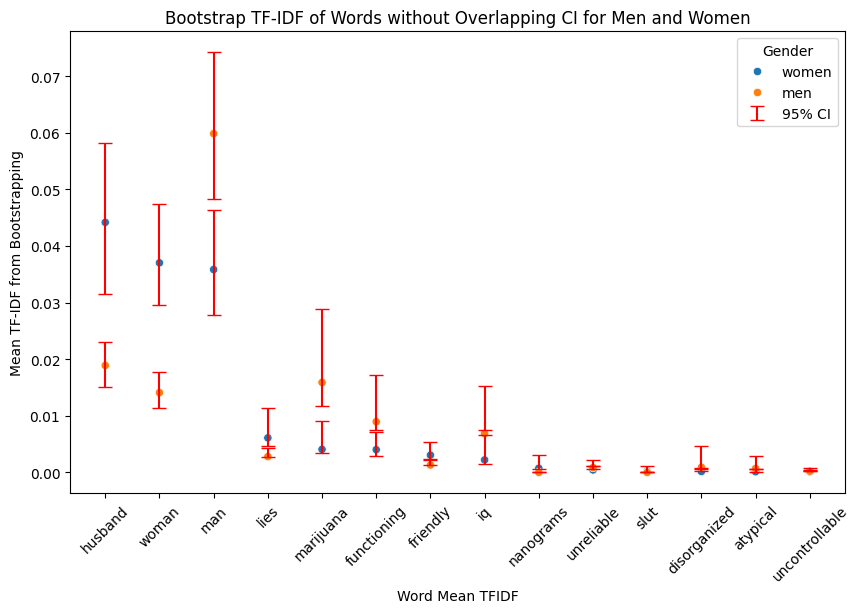

In [135]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 2. Create the dot plot using seaborn.scatterplot
plt.figure(figsize=(10, 6)) # Optional: Adjust figure size for better readability
ax =sns.scatterplot(
    data=df_w_m_tfidf,
    x='feature',         # The column for the x-axis (e.g., categories to group by)
    y='mean_freq',  # The column for the y-axis (e.g., the value)
    hue='gender',
 # The column to use for grouping and coloring the dots
    # s=100,           # Optional: Adjust the size of the dots
    # alpha=0.7        # Optional: Adjust transparency
)

ax.errorbar(
    x=df_w_m_tfidf['feature'],
    y=df_w_m_tfidf['mean_tfidf'],
    yerr=[df_w_m_tfidf['mean_tfidf'] - df_w_m_tfidf['tfidf_ci_low'],df_w_m_tfidf['tfidf_ci_high'] - df_w_m_tfidf['mean_tfidf']],
    fmt='none',          # Do not plot markers for the error bars themselves
    color='red',
    capsize=5,           # Add caps to the error bars
    label='95% CI'
)


ax.tick_params(axis='x', labelrotation=45)
# 3. Customize the plot
plt.title('Bootstrap TF-IDF of Words without Overlapping CI for Men and Women')
plt.xlabel('Word Mean TFIDF')
plt.ylabel('Mean TF-IDF from Bootstrapping')
plt.legend(title='Gender') # Add a legend based on the 'hue' parameter

# 4. Display the plot
plt.show()


In [151]:
def plot_subset_words_ci(data_subset, central_tendency_measure='mean', metric='freq'):

  metric_name = central_tendency_measure +'_' +metric
  ci_low_name = metric+ '_ci_low'
  ci_high_name = metric + '_ci_high'
  if metric =='freq':
    metric_title = 'Term Frequency'
  else:
    metric_title ='TF-IDF'

  plt.figure(figsize=(10, 6)) # Optional: Adjust figure size for better readability
  ax =sns.scatterplot(
      data=data_subset,
      x='feature',         # The column for the x-axis (e.g., categories to group by)
      y=metric_name,  # The column for the y-axis (e.g., the value)
      hue='gender',
  # The column to use for grouping and coloring the dots
      # s=100,           # Optional: Adjust the size of the dots
      # alpha=0.7        # Optional: Adjust transparency
  )

  ax.errorbar(
      x=data_subset['feature'],
      y=data_subset[metric_name],
      yerr=[data_subset[metric_name] - data_subset[ci_low_name],data_subset[ci_high_name] - data_subset[metric_name]],
      fmt='none',          # Do not plot markers for the error bars themselves
      color='red',
      capsize=5,           # Add caps to the error bars
      label='95% CI'
  )


  ax.tick_params(axis='x', labelrotation=45)
  # 3. Customize the plot
  title = 'Bootstrap ' + central_tendency_measure +' '+ metric_title+ ' of Words without Overlapping CI for Men and Women'
  plt.title(title)
  plt.xlabel('Word ' + central_tendency_measure + ' ' + metric)
  plt.ylabel( central_tendency_measure + ' ' + metric + ' from Bootstrapping')
  plt.legend(title='Gender') # Add a legend based on the 'hue' parameter

  # 4. Display the plot
  plt.show()

In [155]:
stat_sig_w_m_tfidf = dataframe_ci_overap[dataframe_ci_overap['women_men_tfidf_ci_overlap'] ==0]['word'].to_list()
stat_sig_w_m_freq = dataframe_ci_overap[dataframe_ci_overap['women_men_freq_ci_overlap'] ==0]['word'].to_list()

stat_sig_w_j_freq = dataframe_ci_overap[dataframe_ci_overap['women_joint_freq_ci_overlap'] ==0]['word'].to_list()
stat_sig_w_j_tfidf = dataframe_ci_overap[dataframe_ci_overap['women_joint_tfidf_ci_overlap'] ==0]['word'].to_list()

stat_sig_m_j_freq = dataframe_ci_overap[dataframe_ci_overap['men_joint_freq_ci_overlap'] ==0]['word'].to_list()
stat_sig_m_j_tfidf = dataframe_ci_overap[dataframe_ci_overap['men_joint_tfidf_ci_overlap'] ==0]['word'].to_list()

In [156]:
stat_sig_w_m_tfidf

['husband',
 'woman',
 'man',
 'lies',
 'marijuana',
 'functioning',
 'friendly',
 'iq',
 'nanograms',
 'unreliable',
 'slut',
 'disorganized',
 'atypical',
 'uncontrollable']

In [157]:
stat_sig_w_m_freq

['husband',
 'woman',
 'man',
 'lies',
 'marijuana',
 'caring',
 'friendly',
 'iq',
 'nanograms',
 'slut',
 'disorganized',
 'atypical']

In [ ]:
df_w_m_tfidf = bootstrap_results[bootstrap_results['feature'].isin(stat_sig_w_m_tfidf)]
df_w_m_tfidf = df_w_m_tfidf[df_w_m_tfidf['gender']!='joint']



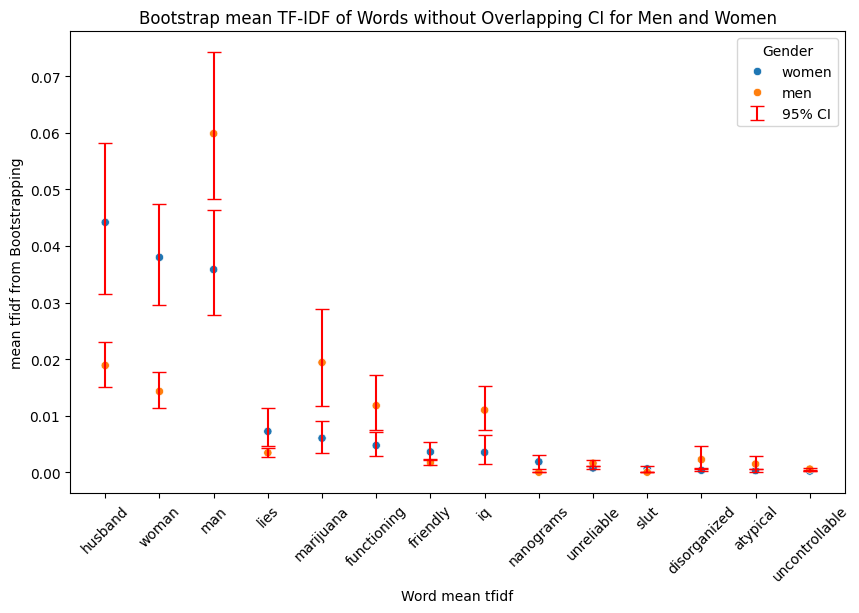

In [152]:
plot_subset_words_ci(df_w_m_tfidf, metric='tfidf')

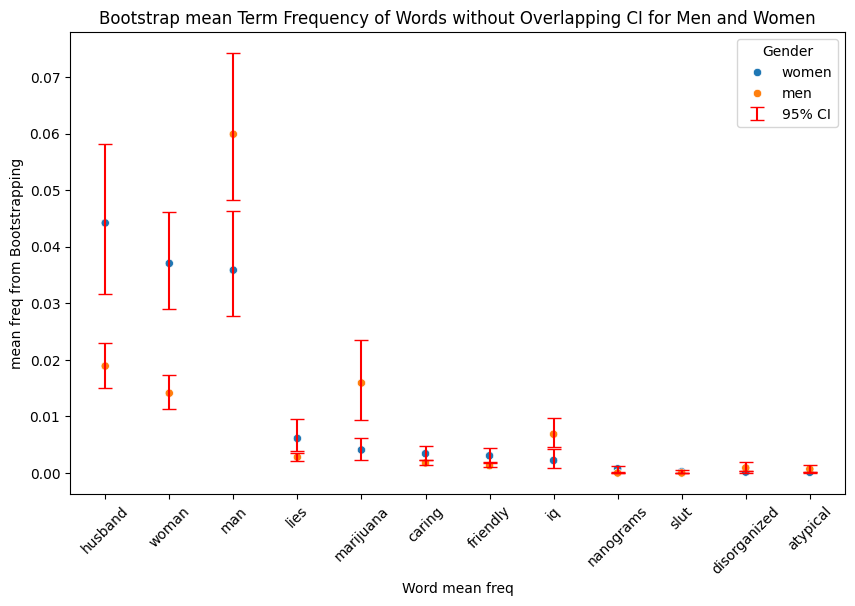

In [154]:
df = bootstrap_results[bootstrap_results['feature'].isin(stat_sig_w_m_freq)]
df = df[df['gender']!='joint']


plot_subset_words_ci(df, central_tendency_measure='mean', metric='freq')

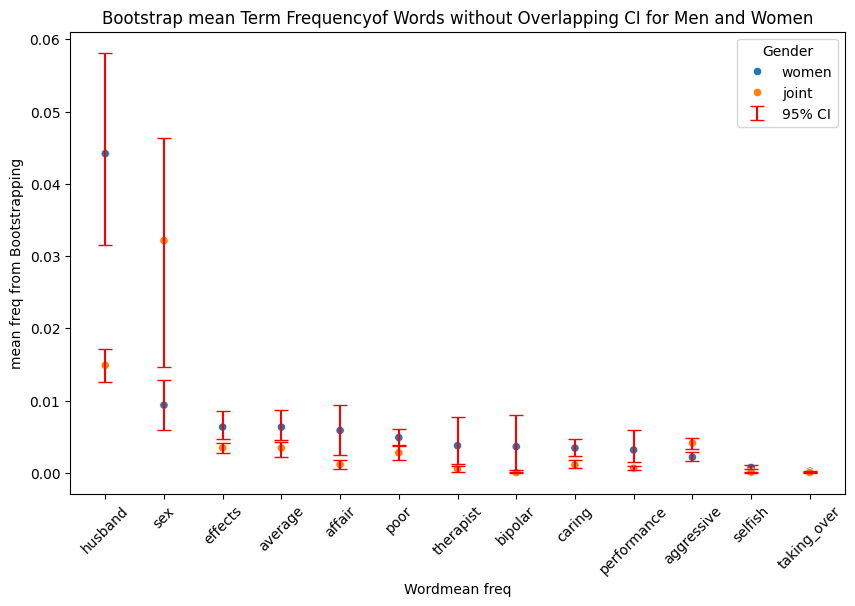

In [147]:
df= bootstrap_results[bootstrap_results['feature'].isin(stat_sig_w_j_freq)]
df = df[df['gender']!='men']

plot_subset_words_ci(df, central_tendency_measure='mean')